# Image Segmentation Basic

* segmentation: 모든 픽셀에 대해 각 픽셀이 어떤 카테고리에 속하는지 분류하는 문제
* segmentation을 위한 neural network 직접 구현
* tensorflow, keras 사용

In [70]:
import os

In [71]:
os.environ['CUDA_VISIBLE_DEVICES'] = '6'

import tensorflow as tf
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

### 1. Data

Oxford-IIIT Pet Dataset

* class1: Pixel belonging to the pet
* class2: Pixel bordering the pet
* class3: None of the above/ Surrounding pixel

In [72]:
import tensorflow_datasets as tfds
tfds.disable_progress_bar()

dataset, info = tfds.load('oxford_iiit_pet:4.*.*', with_info=True)

In [73]:
info

tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/home/jovyan/aicon-gamma-datavol-1/hjgoh/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtyp

In [74]:
print('# of training sampels:', info.splits['train'].num_examples)
print('# of validation sampels:', info.splits['test'].num_examples)

# of training sampels: 3680
# of validation sampels: 3669


#### 1.1 Dataset preprocessing

* imgsz: 128*128
* normalize: 이미지를 0과 1 사이의 실수값, segmentation label을 0~2의 정수값
* load_image_train: data augmentation, random 반전
* load_image_test: resizing, normalization only 

In [75]:
def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask -= 1
    return input_image, input_mask

In [76]:
@tf.function
def load_image_train(datapoint):
    #resize 
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128))

    # augmentation
    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        input_mask = tf.image.flip_left_right(input_mask)

    # normalize
    input_image, input_mask = normalize(input_image, input_mask)

    return input_image, input_mask 

In [77]:
def load_image_test(datapoint):
    # image, mask resize
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128))
    
    # normalize
    input_image, input_mask = normalize(input_image, input_mask)

    return input_image, input_mask

#### 1.2 Data pipeline

tf.data의 batch 구성하기

* dataset['train'], ['test']는 tf.data 모듈에 정의한 tf.data.Dataset!
* tf.data의 API를 이용해 batch를 효율적으로 구성
* map: dataset에 있는 각 data point 하나마다 함수를 적용
* shuffle: BUFFER_SIZE 만큼의 데이터를 buffer에 넣고 셔플
* batch: BATCH_SIZE 만큼의 데이터를 하나의 batch로 묶어줌
* repeat: 해당 데이터셋을 이용할 때, 끝나지 않고 계속해서 batch 구성


In [78]:
TRAIN_LENGTH = info.splits['train'].num_examples
BATCH_SIZE = 64
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

In [79]:
train = dataset['train'].map(load_image_train, num_parallel_calls=tf.data.experimental.AUTOTUNE)
test = dataset['test'].map(load_image_test)

In [80]:
train_dataset = train.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
test_dataset = test.batch(BATCH_SIZE)

#### 1.3 Data Display

* display: image / ground-truth segmentation mask / predicted mask를 보여주는 함수
* take(n): 데이터셋에서 n개의 데이터를 가져오는 함수

In [81]:
def display(display_list):
    plt.figure(figsize=(20, 20))
    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

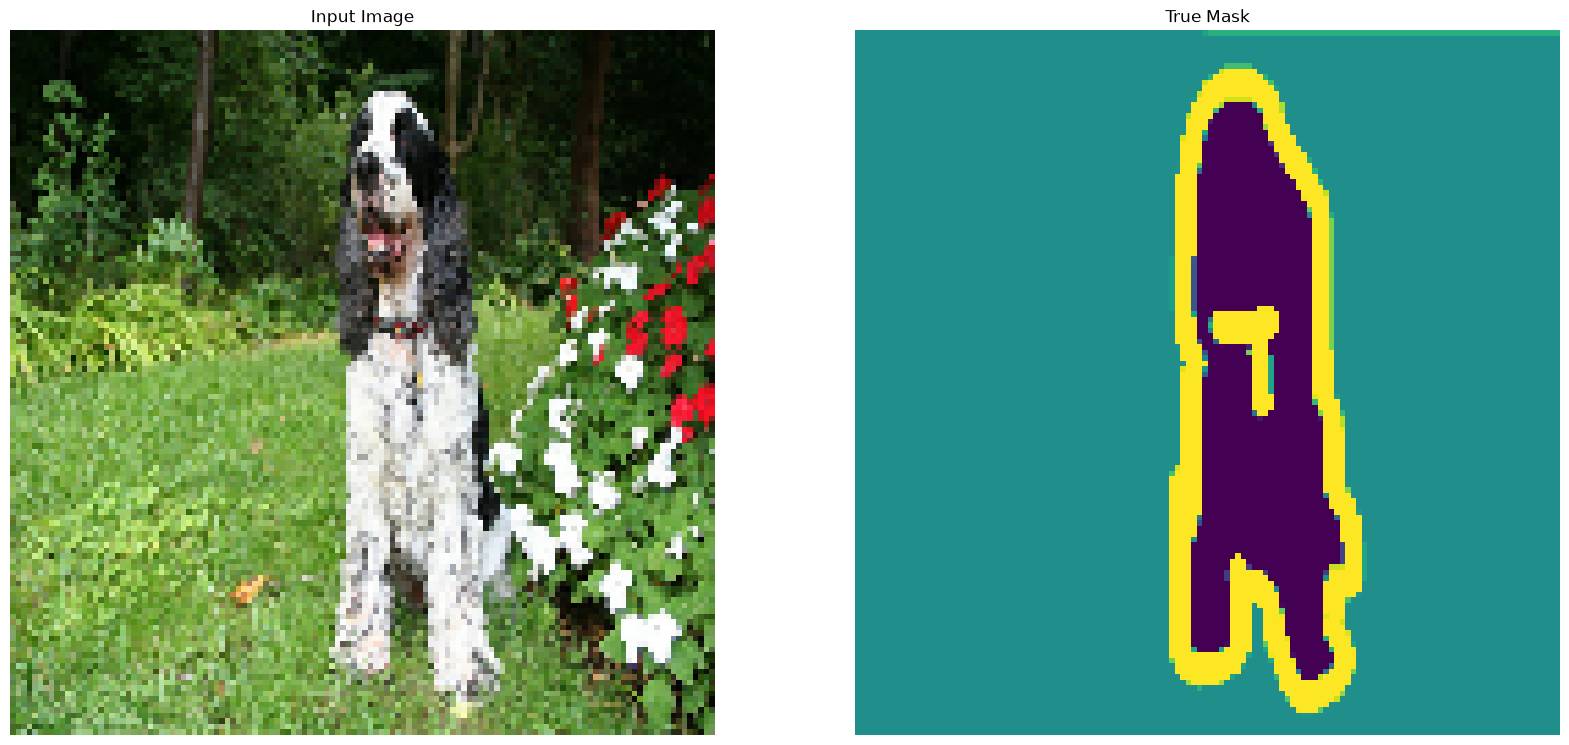

In [82]:
for image, mask in train.take(2):
    sample_image, sample_mask = image, mask
display([sample_image, sample_mask])

### 2. Model Design

* 픽셀 별 prediction
* neural network가 실수(128 x 128 x3)의 RGB 이미지를 입력으로 받고, (128 x 128 x C) 형태의 값을 출력
* C는 카테고리의 수고, 출력의 값은 픽셀의 (i, j)에 대해서 category별 점수로 표현. argmax 함수로 최종 segmentation mask를 assign 가능

In [83]:
OUTPUT_CHANNELS = 3

#### 2.1 Backbone Architecture: MobileNetV2

* pretrained mobilenetv2를 사용
* tf.keras.applications에 정의된 모델
* 모든 layer가 convolution으로 구성된 FCN을 사용
* ImageNet classification dataset에서 pre-trained 된 파라미터를 가지고 와서 fine-tuning!

In [84]:
backbone = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)

layer_names = [
    'block_1_expand_relu',  # 84*84
    'block_3_expand_relu',  # 32*32
    'block_6_expand_relu',  # 16*16
    'block_13_expand_relu', # 8*8
    'block_16_project',     # 4*4
]

layers = [backbone.get_layer(name).output for name in layer_names]

backbone_features = tf.keras.Model(inputs=backbone.input, outputs=layers)
backbone_features.trainable = False

#### 2.2 Segmentation Module Implementation

* backbone architecture가 주어졌을 때 segmentation module을 구현하기
* Keras 사용
* tf.Keras.Model: input-output tensor를 지정하면 그 사이에 연결된 레이어를 묶고, 학습에 필요한 fit, complie 등의 메서드 사용 가능
* tf.Keras.Sequential: layer 하나로 묶어주기
* tf.Keras.layers.Conv2D: conv layer 하나 추가
* tf.Keras.layers.UpSampling2D: 이미지 형태의 input upsampling

In [85]:
# CNN head
def build_example_model():
    # input shape
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])

    # feature
    features = backbone_features(inputs)

    # 사용할 feature map 정하기
    # 4번째째 feature map은 8*8 resolution
    x = features[3]

    # feature map 기반 8*8 segmentation prediction mask를 만드는 CNN 생성
    # pretrained 모델이 뽑은 특징을 픽셀별 클래스 점수로 변환 / head의 역할!
    convnet = tf.keras.Sequential(layers = [
        tf.keras.layers.Conv2D(16, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2D(OUTPUT_CHANNELS, 3, padding='same'), 
        # 8*8 grid를 logit 벡터로 변환, 즉, 점수로 변환
        # 여기에서 softmax를 취해주면 픽셀별 클래스 확률! 
    ])
    x = convnet(x)

    # 8*8 출력값을 bilinear interpolation으로 128*128 업샘플 
    upsample = tf.keras.layers.UpSampling2D(
        size = (16, 16),
        interpolation = 'bilinear'
    )
    x = upsample(x)

    # x를 최종 출력값으로 갖는 모델을 만들기
    # 최종 상태: 확률이 되기 전의 logit, 입 출력의 크기 맞춤
    return tf.keras.Model(inputs=inputs, outputs=x)
    

### 3. Training

#### 3.1 Compile

* 정의한 함수로 모델을 실제로 만들고 컴파일
* compile: tf.keras.Model을 학습할 때 사용할 optimizer, loss, evaluation에 사용할 metrix 설저정
* optimizer: adam
* loss: losses.SparseCategoricalCrossentropy(fron_logits=True) / category에 해당하는 채널의 값이 높아지도록 학습

* visualization function
* create_mask: 모델 출력값으로 segmentation mask 만드는 함수
* show_predictions: model 이용해서 prediction + visualization
* tf.keras.utils.plot_model: 모델 구조 visulaization / input, output shape 확인해서 모델이 잘 정의됐는지 확인

In [109]:
# model = build_example_model()
model = build_deeper_model()

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [166]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[0]

def show_predictions(dataset=None, num=1):
    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = model.predict(image)
            display([image[1], mask[1], create_mask(pred_mask)])

    else: 
        display([sample_image, sample_mask, create_mask(model.predict(sample_image[tf.newaxis, ...]))])

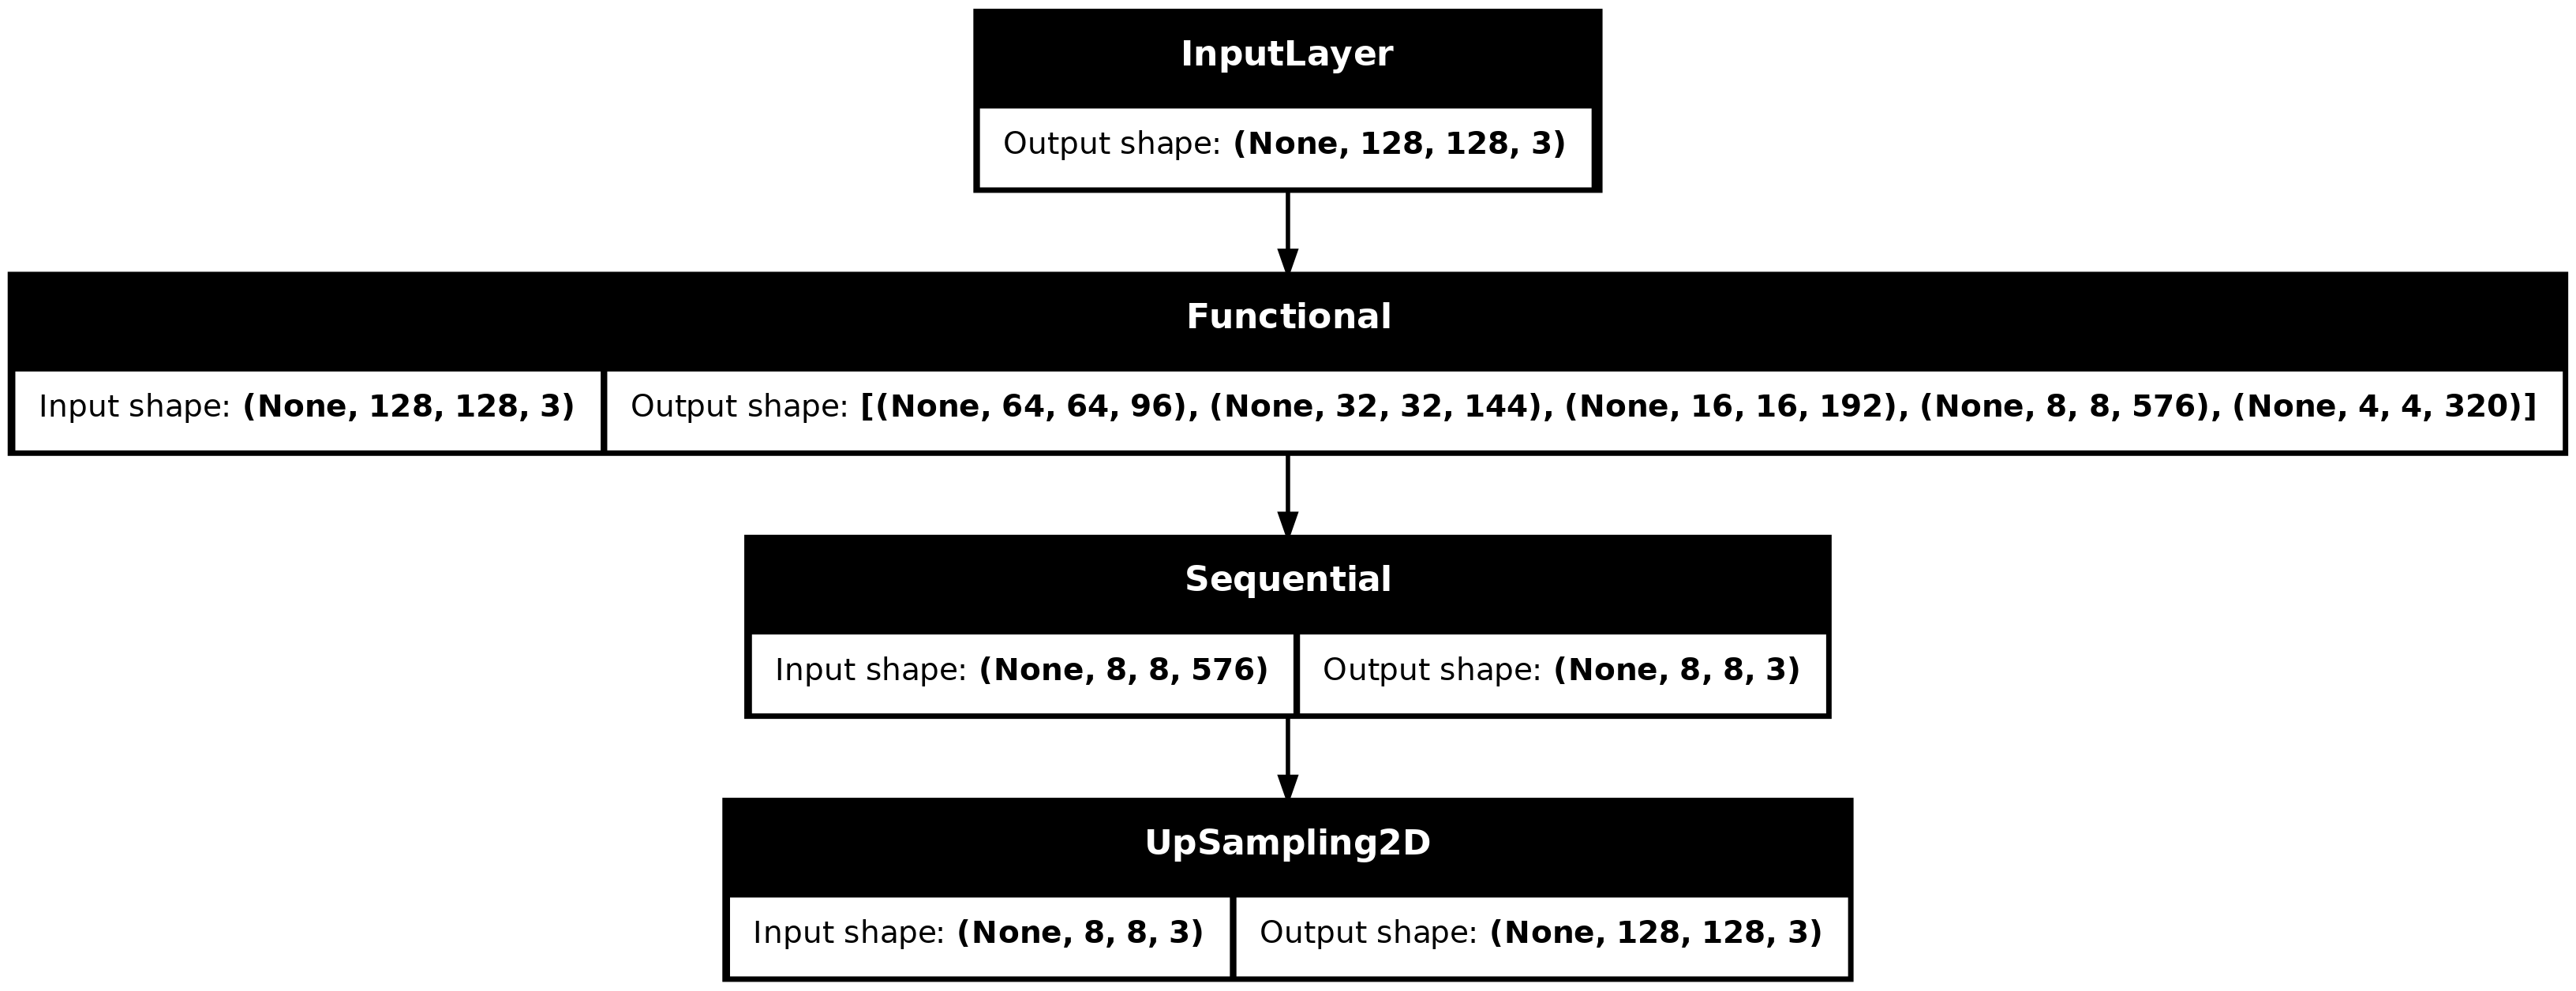

In [88]:
tf.keras.utils.plot_model(model, show_shapes=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step


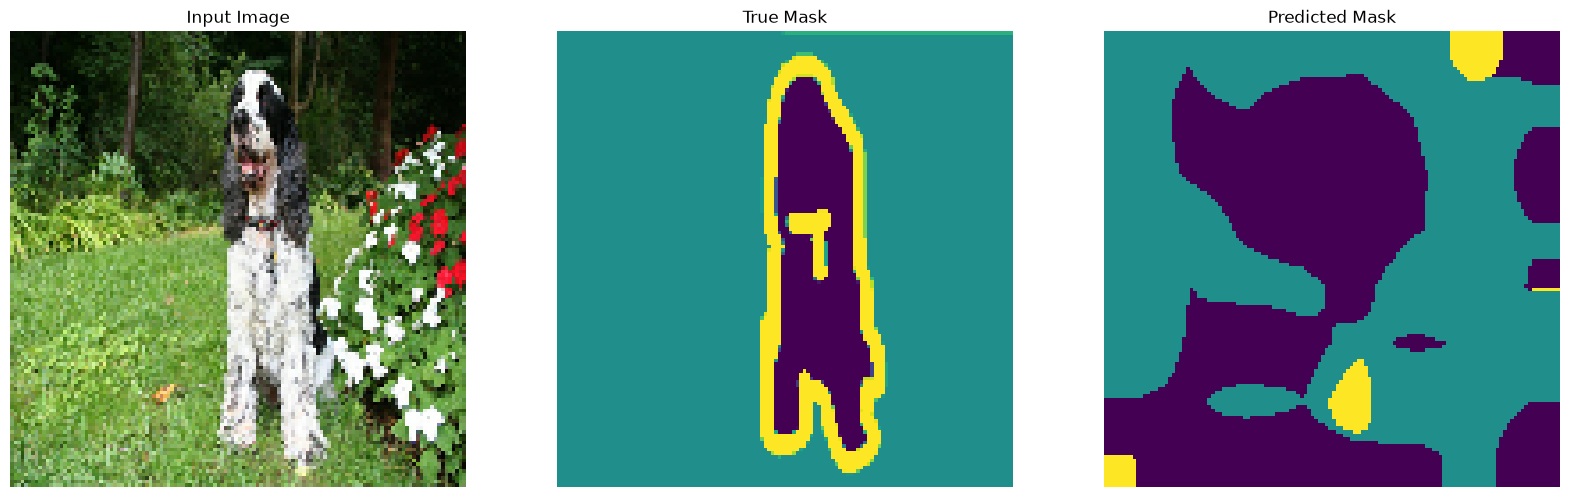

In [89]:
show_predictions()

#### 3.2 Training

* model.fit으로 모델 학습
* on_epoch_end: 학습마다 training epoch이 끝날 때마다 호출
* clear_output 함수를 이용해서 이전에 띄운 결과를 지우고 새로운 결과를 visualization

In [90]:
class DisplayCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        clear_output(wait=True)
        show_predictions()
        print('\nSample Prediction after epoch{}\n'.format(epoch+1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


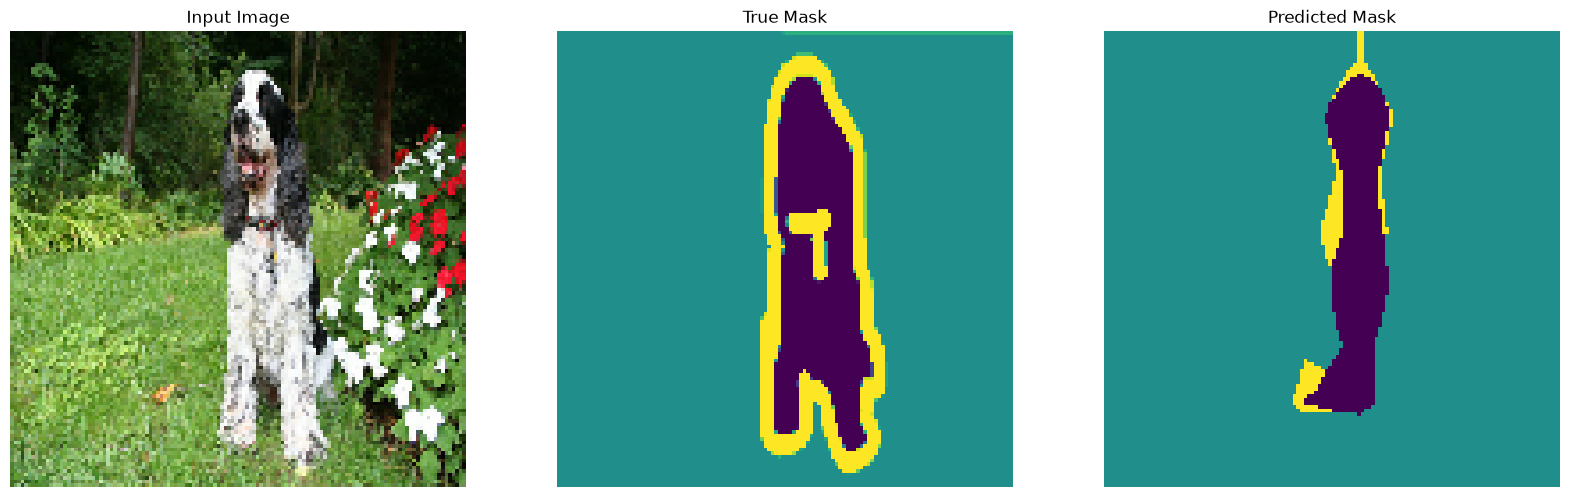


Sample Prediction after epoch10

57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 321ms/step - accuracy: 0.8676 - loss: 0.2978 - val_accuracy: 0.8667 - val_loss: 0.3060


In [110]:
EPOCHS = 10 
VAL_SUBSPLITS = 10
VALIDATION_STEPS = info.splits['test'].num_examples//BATCH_SIZE//VAL_SUBSPLITS

model_history = model.fit(
    train_dataset, 
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=test_dataset,
    callbacks=[DisplayCallback()],
)

### 4. Evaluation

* 정량 평가
* training loss, validation loss 확인
* picel accuracy 확인

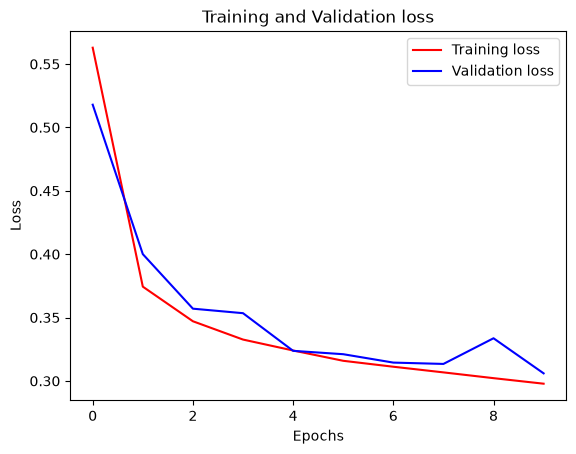

In [112]:
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(EPOCHS)

plt.figure()
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'blue', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

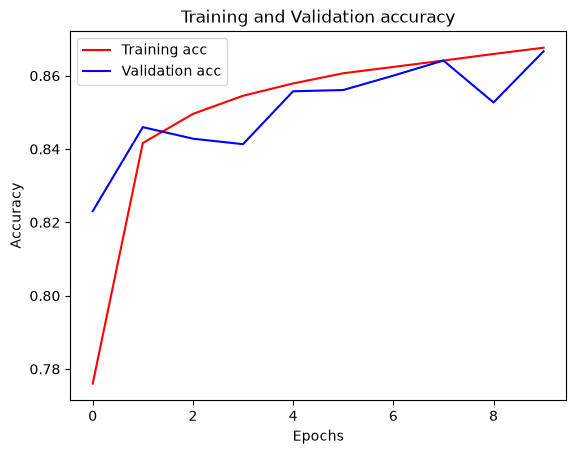

In [113]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']

plt.figure()
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'blue', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

* pixel acc
    * 전체 이미지 중 예측과 정답이 같은 픽셀의 비율

* dice 
    * 2*교집합/(예측 크기 + 정답 크기)

* iou
    * 교집합 / 합집합
    * 합집합 = 둘을 더하고 겹친 부분 한 번 빼기

In [114]:
# pixel accuracy, dice score, iou
def compute_segmentation_metrics(model, test_dataset, num_classes=OUTPUT_CHANNELS, num_batches=None):
    total_correct = 0
    total_pixels = 0
    dice_sum = np.zeros(num_classes)
    iou_sum = np.zeros(num_classes)
    n_images = 0

    for i, (image, true_mask) in enumerate(test_dataset):
        if num_batches is not None and i >= num_batches:
            break
        
        pred_logits = model.predict(image, verbose=0)
        pred_masks = tf.argmax(pred_logits, axis=-1)
        true_masks = tf.squeeze(true_mask, axis=-1)
        true_masks = tf.cast(true_masks, tf.int64)

        # pixel acc: 전체 배치 누적
        correct = tf.reduce_sum(tf.cast(tf.equal(pred_masks, true_masks), tf.float32))
        total_correct += correct.numpy()
        total_pixels += tf.size(true_masks).numpy()

        # dice / iou
        batch_size = image.shape[0]
        for b in range(batch_size):
            pred_mask = pred_masks[b]
            true_mask = true_masks[b]

            # dice
            for c in range(num_classes):
                pred_c = tf.cast(tf.equal(pred_mask, c), tf.float32)
                true_c = tf.cast(tf.equal(true_mask, c), tf.float32)

                intersection = tf.reduce_sum(pred_c * true_c)
                pred_sum = tf.reduce_sum(pred_c)
                true_sum = tf.reduce_sum(true_c)
                union = pred_sum + true_sum - intersection

                dice = (2 * intersection + 1e-7) / (pred_sum + true_sum + 1e-7)
                iou = (intersection + 1e-7) / (union + 1e-7)
                dice_sum[c] += dice.numpy()
                iou_sum[c] += iou.numpy()
            n_images += 1

    pixel_acc = total_correct / total_pixels
    dice_per_class = dice_sum / n_images
    iou_per_class = iou_sum / n_images
    return pixel_acc, dice_per_class, iou_per_class

pixel_acc, dice_per_class, iou_per_class = compute_segmentation_metrics(model, test_dataset)

def print_segmentation_metrics(pixel_acc, dice_per_class, iou_per_class, class_names=('pet', 'border', 'background'), model_name=None):
    if model_name is not None:
        print(f"\n{'='*50}\n{model_name}\n{'='*50}")

    print(f"Pixel Accuracy: {pixel_acc:.4f}\n")
    print(f"{'class':<15}{'Dice':>10}{'IoU':>10}")
    for c, name in enumerate(class_names):
        print(f"{name:<12}{dice_per_class[c]:>10.4f}{iou_per_class[c]:>10.4f}")
    print(f"{'mean':<12}{dice_per_class.mean():>10.4f}{iou_per_class.mean():>10.4f}")

print_segmentation_metrics(pixel_acc, dice_per_class, iou_per_class, class_names=('pet', 'border', 'background'), model_name=None)

Pixel Accuracy: 0.8674

class                Dice       IoU
pet             0.8497    0.7508
border          0.9177    0.8555
background      0.3793    0.2423
mean            0.7156    0.6162


* 정성 평가
* test sample에 대한 예측

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


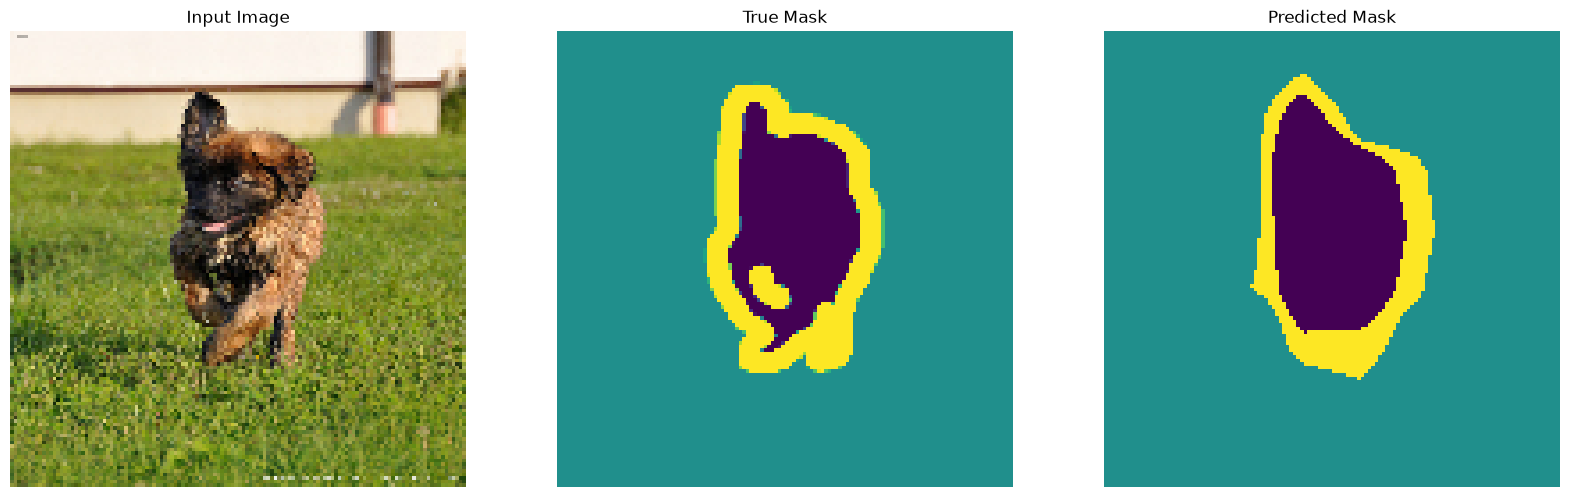

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step


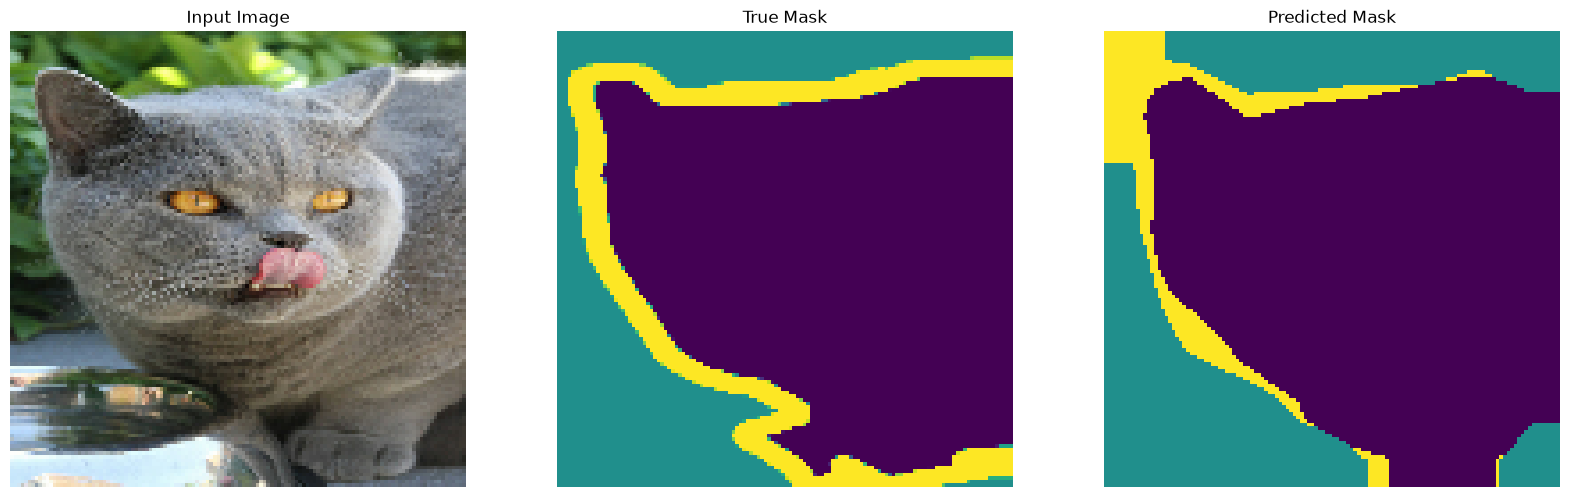

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


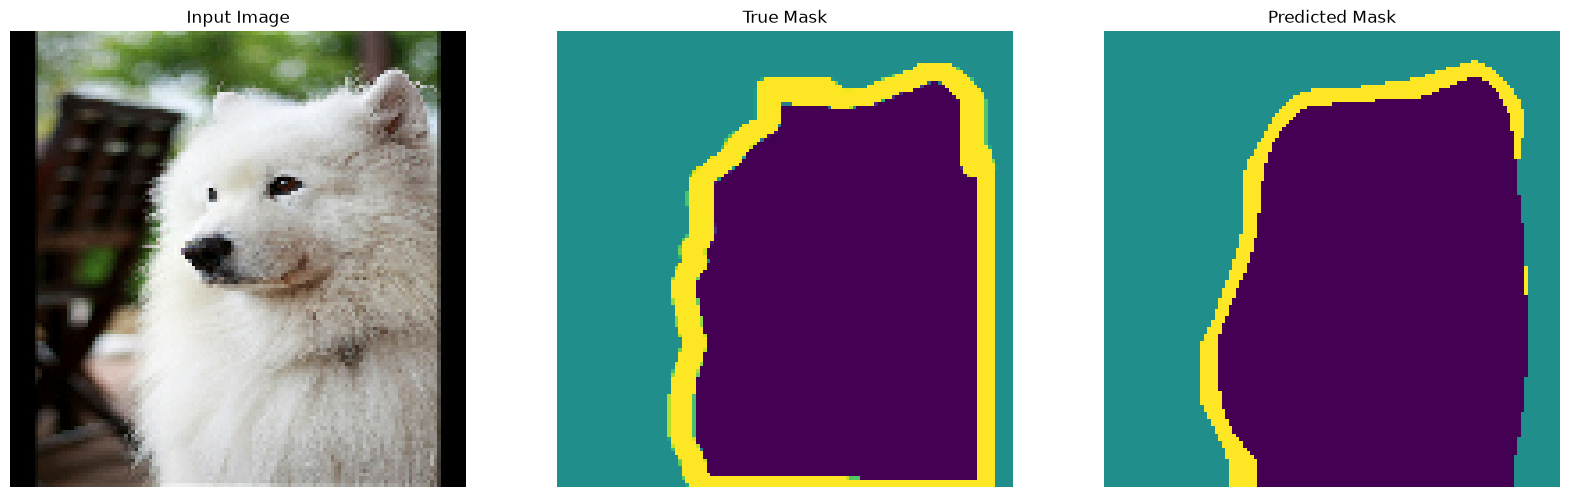

In [95]:
show_predictions(test_dataset, 3)

### Task

* 모델 개선을 위한 태스크
* build_example_model 함수와 비슷한 역할의 함수 정의
* 모델 학습
* 모델 평가
* 변화 관측

#### task1: Deeper Architecture

* MobileNetV2 architecture의 8*8 feature map -- 2개의 convolutional layer
* 더 많은 수의 layer를 사용할 경우 어떤 식으로 개선되는지
* convolutional layer의 width를 늘리면 어떻게 되는지
* model = build_example_model() ---> model = build_deeper_model()

* Q) layer를 하나 더 사용 / width 16 -> 32로 확장
* Q) 고려해볼 수 있는 다른 조합
* Q) architecture에 따른 성능 차이

In [96]:
def build_deeper_model():
    # input shape
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])

    # feature
    features = backbone_features(inputs)
    x = features[3]

    # CNN head
    convnet = tf.keras.Sequential(
        layers = [
            tf.keras.layers.Conv2D(16, 3, padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Conv2D(16, 3, padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Conv2D(OUTPUT_CHANNELS, 3, padding='same'),
        ]
    )
    x = convnet(x)

    # 8*8 출력값을 bilinear interpolation으로 128*128 업샘플
    upsample = tf.keras.layers.UpSampling2D(
        size = (16, 16),
        interpolation = 'bilinear'
    )
    x = upsample(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

#### task2: Use High-Resolution Feature Maps

* 8x8 resolution + 16x16 bilinear interpolation -> 16x16 resolution + 16x16 interpolation? 

* Q) (Optional) 다른 resolution의 feature map
* Q) (Optional) 어떤 resolution을 사용하는 것이 성능이 가장 높은가? 또, resolution에 따른 장단점

In [ ]:
# build_for_resolution_model()
def build_for_resolution_model(feature_idx):
    # input shape
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])
    features = backbone_features(inputs)
    x = features[feature_idx]

    convnet = tf.keras.Sequential(
        layers = [
            # kernel(출력 채널) 개수: 16 
            tf.keras.layers.Conv2D(16, 3, padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Conv2D(OUTPUT_CHANNELS, 3, padding='same'),
        ]
    )
    x = convnet(x)

    upsample_ratio = 128 // x.shape[1]
    upsample = tf.keras.layers.UpSampling2D(
        size = (upsample_ratio, upsample_ratio),
        interpolation = 'bilinear'
    )

    x = upsample(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


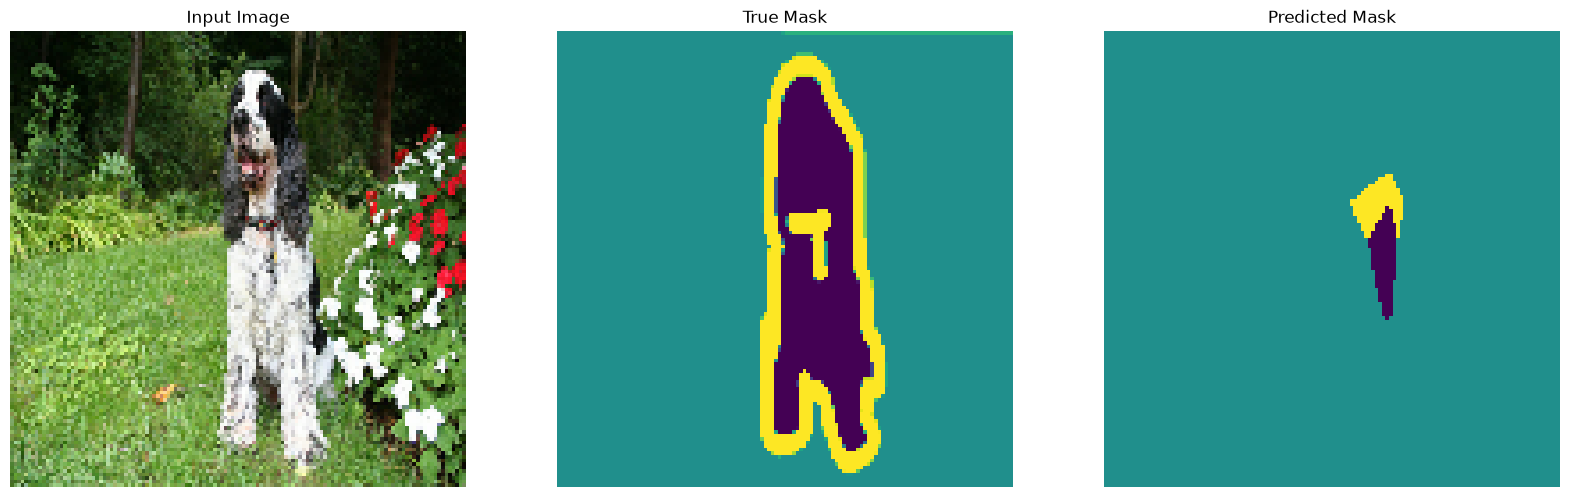


Sample Prediction after epoch10

57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 367ms/step - accuracy: 0.8007 - loss: 0.4834 - val_accuracy: 0.7945 - val_loss: 0.4964


In [102]:
results = {}
histories = {}
models = {}

for idx, name in enumerate(layer_names):
    model = build_for_resolution_model(idx)
    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    history = model.fit(
        train_dataset, 
        epochs=EPOCHS,
        steps_per_epoch=STEPS_PER_EPOCH,
        validation_steps=VALIDATION_STEPS,
        validation_data=test_dataset,
        callbacks=[DisplayCallback()],
    )
    results[name] = history.history['val_accuracy'][-1]
    histories[name] = history
    models[name] = model
    print(f"Model {name} trained over")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


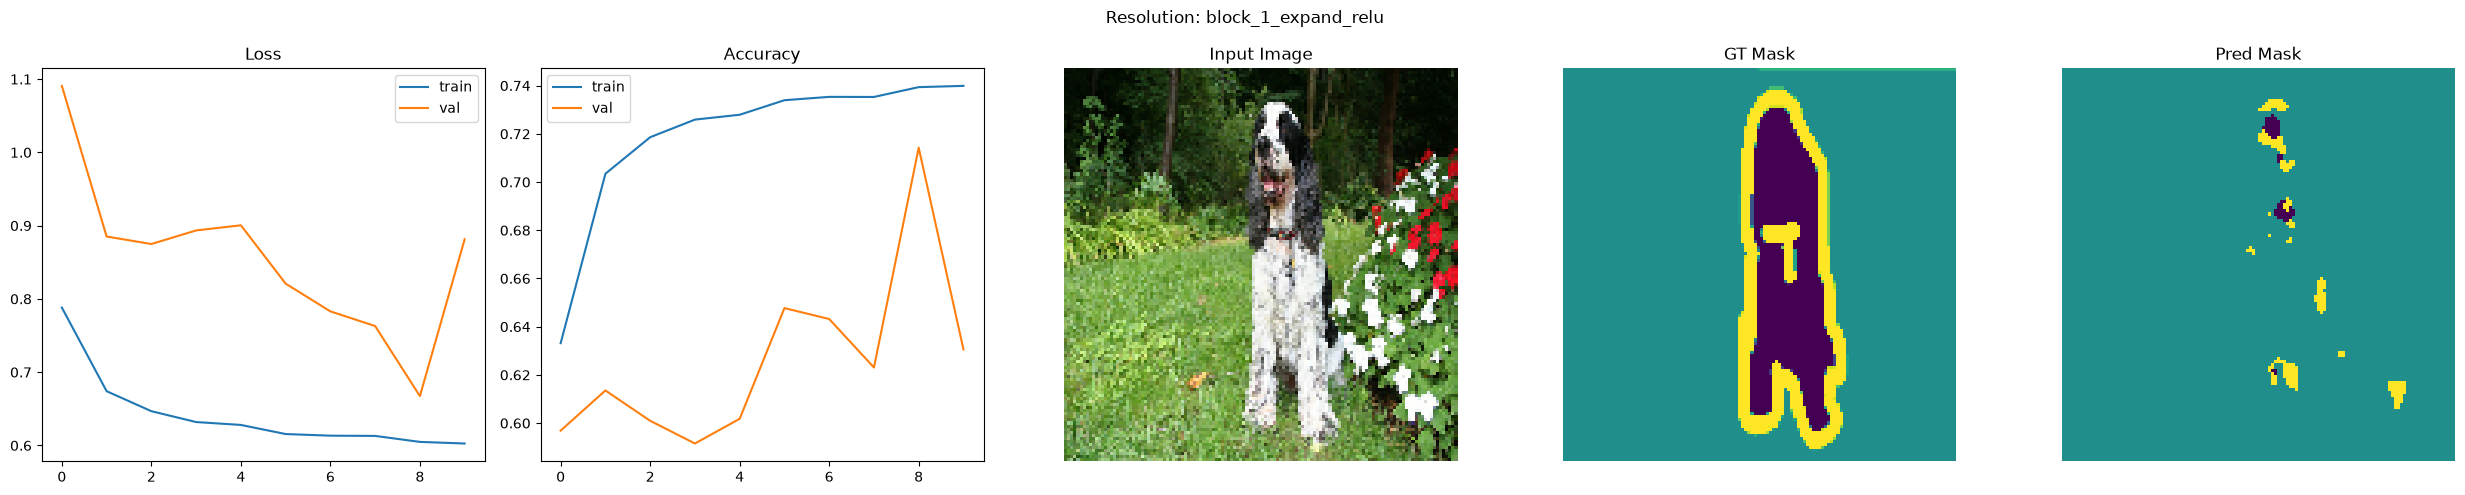

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


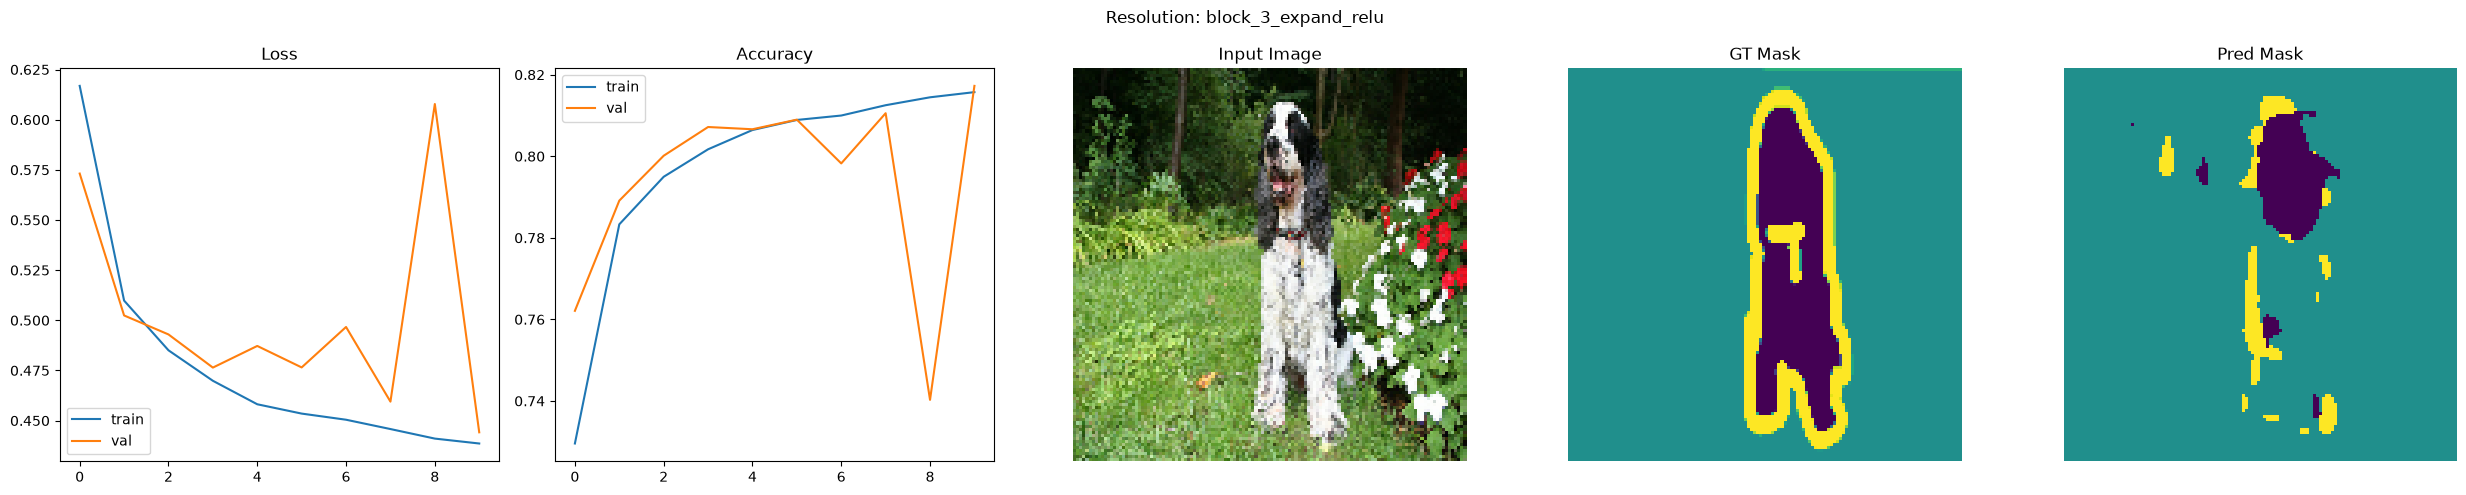

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


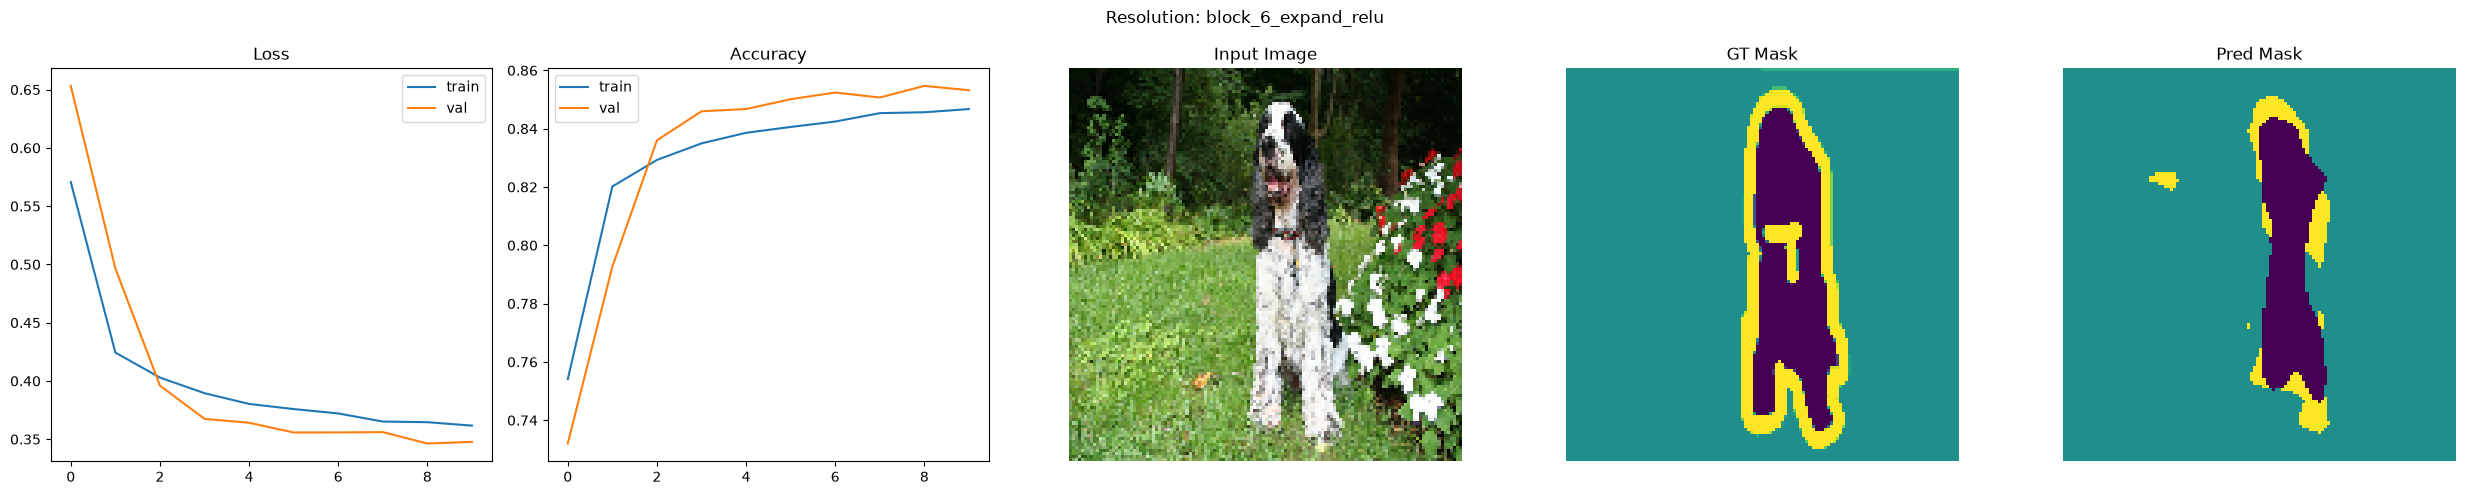

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


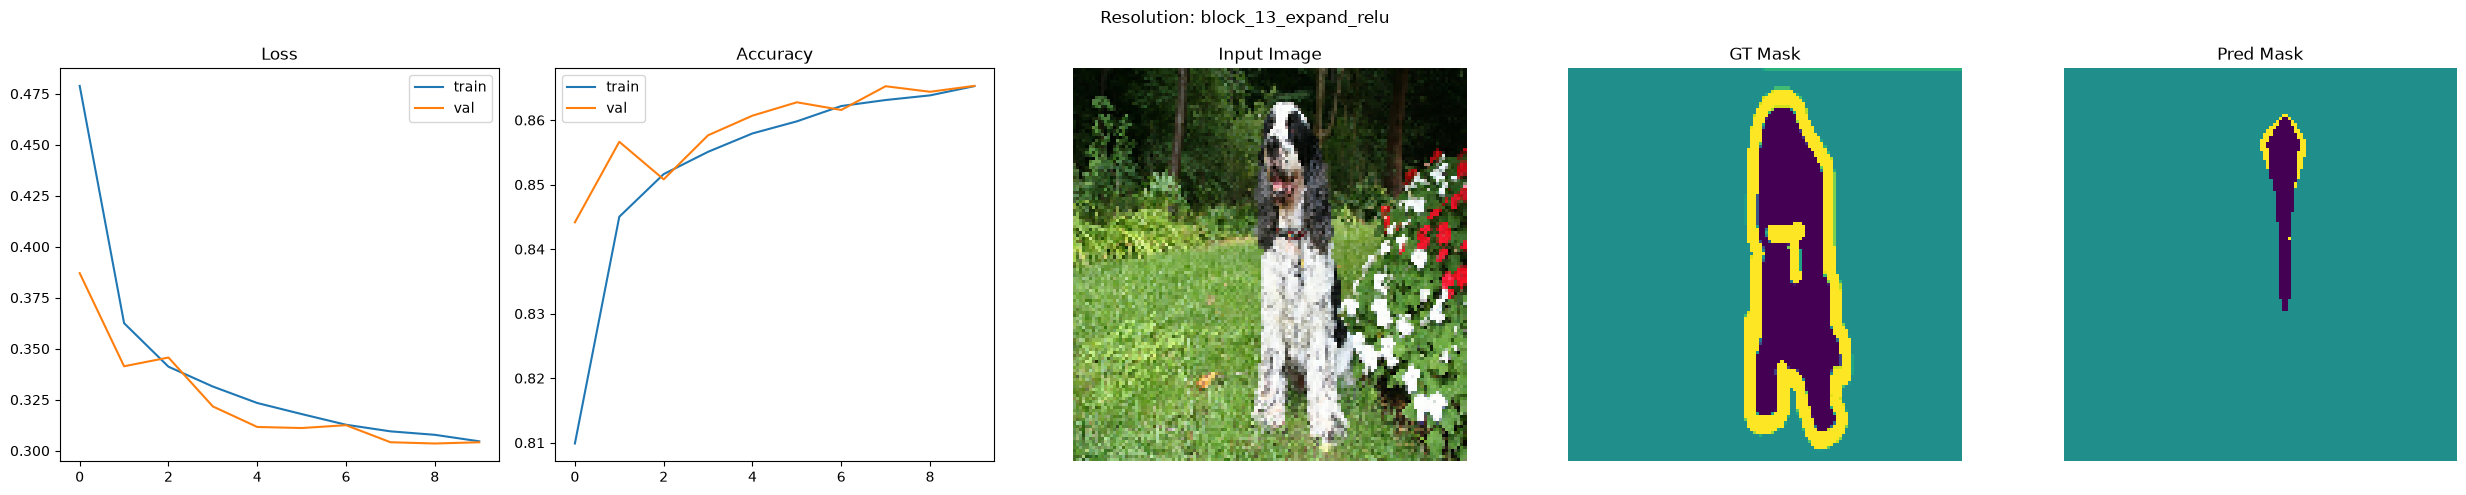

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


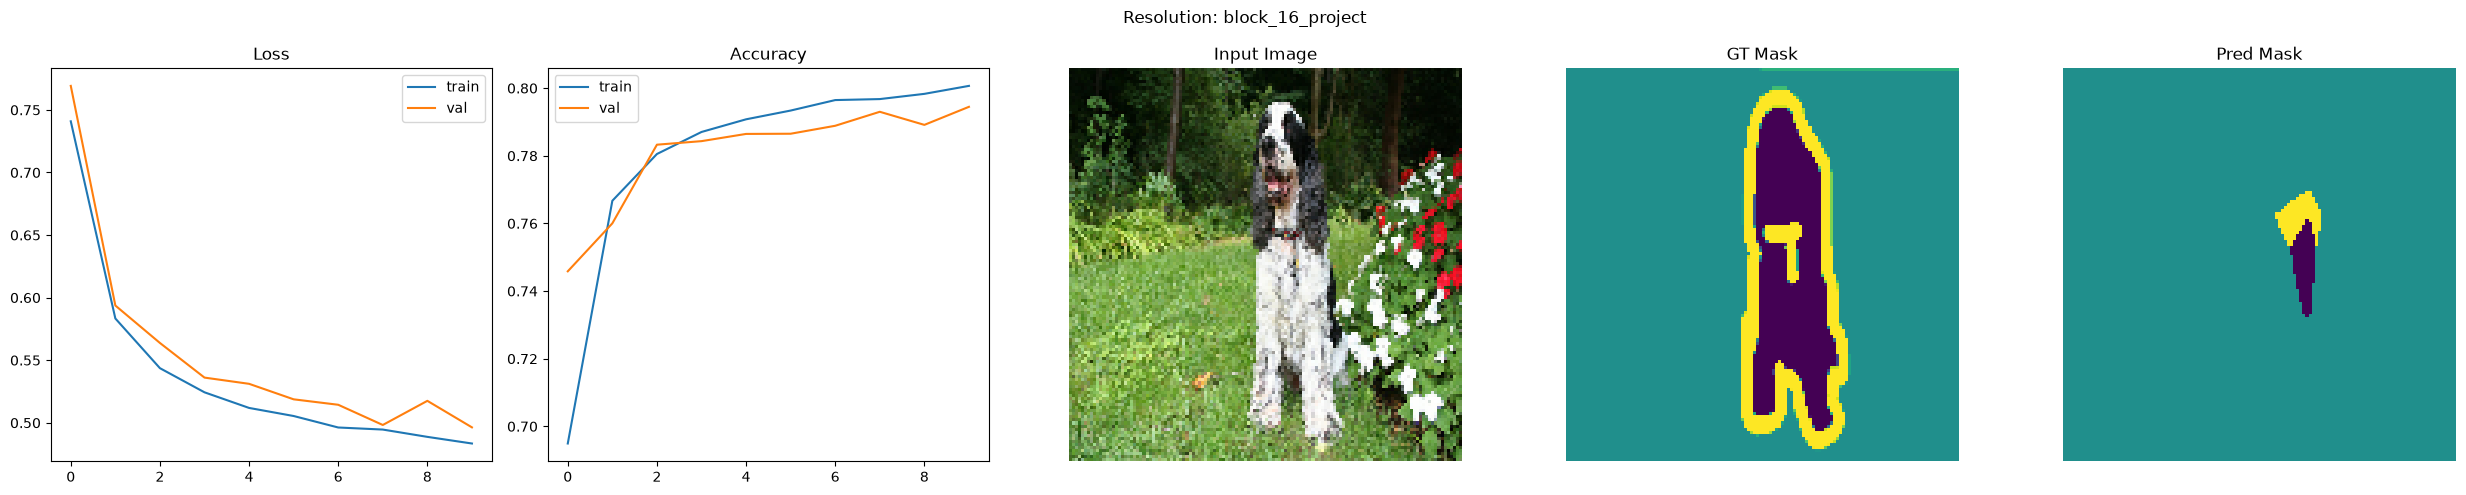

In [103]:
# evlauation
# resolution 별로 정성평가
for name in layer_names:
    model = models[name]
    history = histories[name]
    pred_mask = create_mask(
        model.predict(sample_image[tf.newaxis, ...])
    )
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(f"Resolution: {name}")
    axes[0].plot(history.history['loss'], label='train'); axes[0].plot(history.history['val_loss'], label='val'); axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history.history['accuracy'], label='train'); axes[1].plot(history.history['val_accuracy'], label='val'); axes[1].set_title('Accuracy'); axes[1].legend()
    axes[2].imshow(tf.keras.preprocessing.image.array_to_img(sample_image)); axes[2].set_title('Input Image'); axes[2].axis('off')
    axes[3].imshow(tf.keras.preprocessing.image.array_to_img(sample_mask)); axes[3].set_title('GT Mask'); axes[3].axis('off')
    axes[4].imshow(tf.keras.preprocessing.image.array_to_img(pred_mask)); axes[4].set_title('Pred Mask'); axes[4].axis('off')
    plt.tight_layout()
    plt.show()

In [118]:
# resolution 별로 정량평가
eval_results = {}

for name in layer_names:
    pixel_acc, dice_scores, iou_scores = compute_segmentation_metrics(models[name], test_dataset)
    eval_results[name] = {
        'pixel_acc': pixel_acc,
        'dice_scores': dice_scores.mean(),
        'iou_scores': iou_scores.mean()
    }

# 전체 출력 / 전체 비교
print("Feature 별 결과")
for name in layer_names:
    m = eval_results[name]
    print(f"\n {name:<25} pixel_acc: {m['pixel_acc']:.4f} dice: {m['dice_scores'].mean():.4f} iou: {m['iou_scores'].mean():.4f}")

print("\n 성능 순위")
for rank, (name, model) in enumerate(sorted(eval_results.items(), key=lambda x: -x[1]['dice_scores']), start=1):
    print(f"\n {rank}위: {name} - pixel_acc: {eval_results[name]['pixel_acc']:.4f} mean dice: {eval_results[name]['dice_scores']:.4f} mean iou: {eval_results[name]['iou_scores']:.4f}")

Feature 별 결과

 block_1_expand_relu       pixel_acc: 0.6447 dice: 0.4311 iou: 0.3190

 block_3_expand_relu       pixel_acc: 0.8215 dice: 0.7100 iou: 0.5872

 block_6_expand_relu       pixel_acc: 0.8545 dice: 0.7184 iou: 0.6098

 block_13_expand_relu      pixel_acc: 0.8661 dice: 0.7241 iou: 0.6215

 block_16_project          pixel_acc: 0.7930 dice: 0.5607 iou: 0.4692

 성능 순위

 1위: block_13_expand_relu - pixel_acc: 0.8661 dice: 0.7241 iou: 0.6215

 2위: block_6_expand_relu - pixel_acc: 0.8545 dice: 0.7184 iou: 0.6098

 3위: block_3_expand_relu - pixel_acc: 0.8215 dice: 0.7100 iou: 0.5872

 4위: block_16_project - pixel_acc: 0.7930 dice: 0.5607 iou: 0.4692

 5위: block_1_expand_relu - pixel_acc: 0.6447 dice: 0.4311 iou: 0.3190


#### task3: Use Multi-resolution Feature Maps(FCN)

* 여러 개의 resolution을 동시에 사용하는 방식
* 각각 다른 resolution의 feature map을 upsampling 한 다음에 사용하는 것

1. feature로부터 여러 종류의 feature map 추출
2. tf.keras.layers.UpSampling2D 함수 이용해서 16x16 해상도를 가지도록 upsampling
3. tf.keras.layers.Concetenate 함수 이용해서 여러 featrue map을 하나로 합치기
<br> concat_layer = tf.keras.layers.Concatenate() 선언
<br> concat_layer([x1, x2, x3]) 형태로 넣기
4. convnet 을 통과, bilinear interpolation 이용해서 128x128 resolution prediction 만들기

In [121]:
def build_multries_model():
    # input shape
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])

    # feature
    features = backbone_features(inputs)

    # upsampling - 모두 16*16 해상도로 업샘플링
    upsample1 = tf.keras.layers.UpSampling2D(
        size = (4, 4), interpolation = 'bilinear'
    )
    upsampe2 = tf.keras.layers.UpSampling2D(
        size = (2, 2), interpolation = 'bilinear'
    )
    x1 = upsample1(features[4])
    x2 = upsampe2(features[3])
    x3 = features[2]

    # concat
    concat_layer = tf.keras.layers.Concatenate()
    x = concat_layer([x1, x2, x3])

    # concat feature map 기반으로 CNN head 생성
    convnet = tf.keras.Sequential(
        layers = [
            tf.keras.layers.Conv2D(16, 3, padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Conv2D(OUTPUT_CHANNELS, 3, padding='same'),
        ]
    )
    x = convnet(x)

    # 최종 128*128로 업샘플 
    upsample = tf.keras.layers.UpSampling2D(
        size = (8, 8),
        interpolation = 'bilinear'
    )
    x = upsample(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step


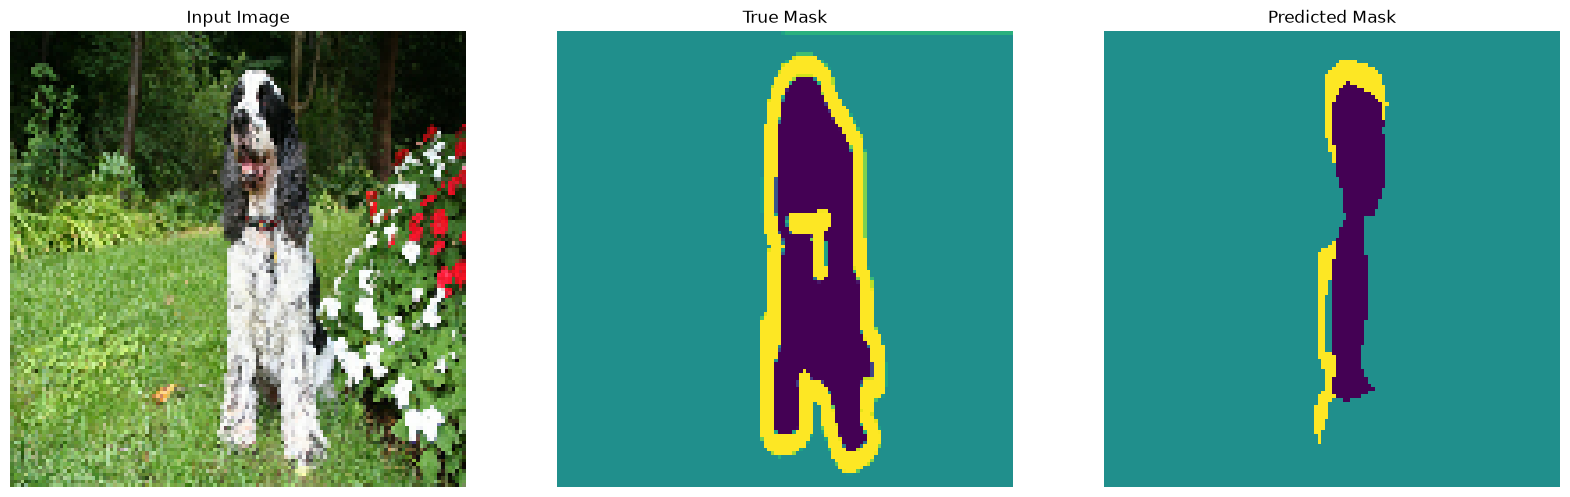


Sample Prediction after epoch10

57/57 ━━━━━━━━━━━━━━━━━━━━ 22s 386ms/step - accuracy: 0.8903 - loss: 0.2526 - val_accuracy: 0.8890 - val_loss: 0.2595


In [123]:
model_name = "multi_res_2_3_4" 

model = build_multries_model()
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
history = model.fit(
    train_dataset, 
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=test_dataset,
    callbacks=[DisplayCallback()],
)
models[model_name] = model
histories[model_name] = history

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


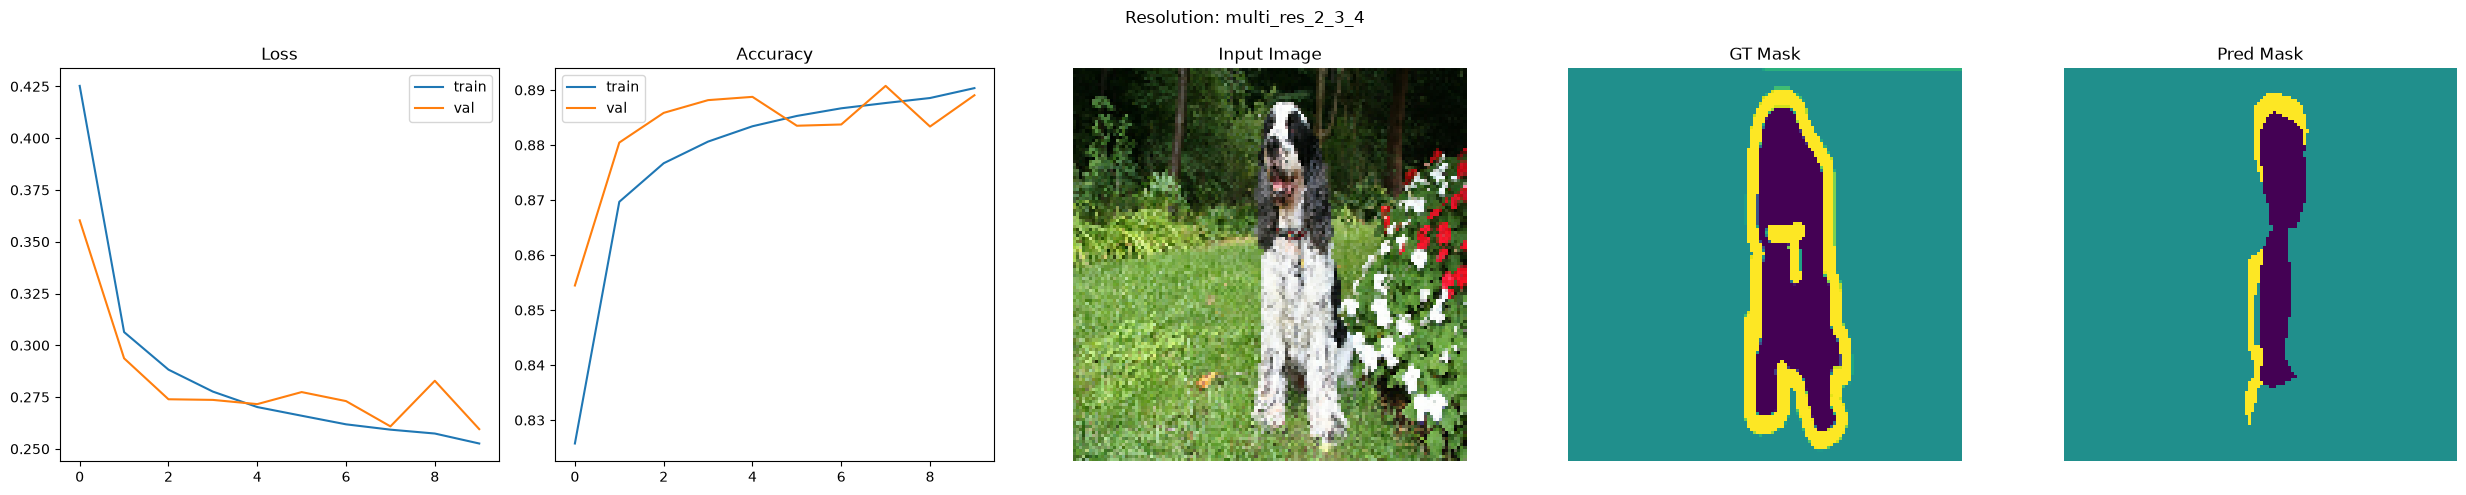

In [127]:
name = 'multi_res_2_3_4'   # 보고 싶은 resolution 하나만 지정

# 정성평가
model = models[name]
history = histories[name]
pred_mask = create_mask(model.predict(sample_image[tf.newaxis, ...]))

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle(f"Resolution: {name}")
axes[0].plot(history.history['loss'], label='train'); axes[0].plot(history.history['val_loss'], label='val'); axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train'); axes[1].plot(history.history['val_accuracy'], label='val'); axes[1].set_title('Accuracy'); axes[1].legend()
axes[2].imshow(tf.keras.preprocessing.image.array_to_img(sample_image)); axes[2].set_title('Input Image'); axes[2].axis('off')
axes[3].imshow(tf.keras.preprocessing.image.array_to_img(sample_mask)); axes[3].set_title('GT Mask'); axes[3].axis('off')
axes[4].imshow(tf.keras.preprocessing.image.array_to_img(pred_mask)); axes[4].set_title('Pred Mask'); axes[4].axis('off')
plt.tight_layout()
plt.show()

In [128]:
# 정량평가
pixel_acc, dice_scores, iou_scores = compute_segmentation_metrics(models[name], test_dataset)
print(f"{name:<25} pixel_acc: {pixel_acc:.4f} dice: {dice_scores.mean():.4f} iou: {iou_scores.mean():.4f}")

multi_res_2_3_4           pixel_acc: 0.8898 dice: 0.7750 iou: 0.6754


#### task4: Use Convolution Transpose

* upsampling (bilinear interpolation) 대신 convolution transpose를 사용한 high-resolution mask
* tf.keras.layers.Conv2DTranspose 함수를 사용, transposed convolution filter를 사용하면서 resolution 늘릴 수 


In [ ]:
# [example]
# x.shape = [8 ,8, 512]
layer = tf.keras.layers.Conv2DTranspose(256, 3, stride=2, padding='same')
y = layer(x)

# y.shape = [16, 16, 256]

* Q) 8x8 resolution map -> 4개의 Conv2D Transpose & 마지막 Conv2D 를 사용 
* Q) bilinear interpolation만 사용하는 모델(build_example_model)과 어떤 차이?

In [135]:
def bulid_deconvnet():
    # input shape
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])

    # featrue map
    features = backbone_features(inputs)
    x = features[3] # 8*8 resolution

    # upsampling 없이! 128*128 해상도록 deconvolution
    deconvnet = tf.keras.Sequential(
        layers =[
            tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Conv2DTranspose(OUTPUT_CHANNELS, 3, strides=1, padding='same'),
        ]
    )
    x = deconvnet(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

In [ ]:
model_name = 'block_13_expand_relu' 

model = bulid_deconvnet()
show_predictions()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


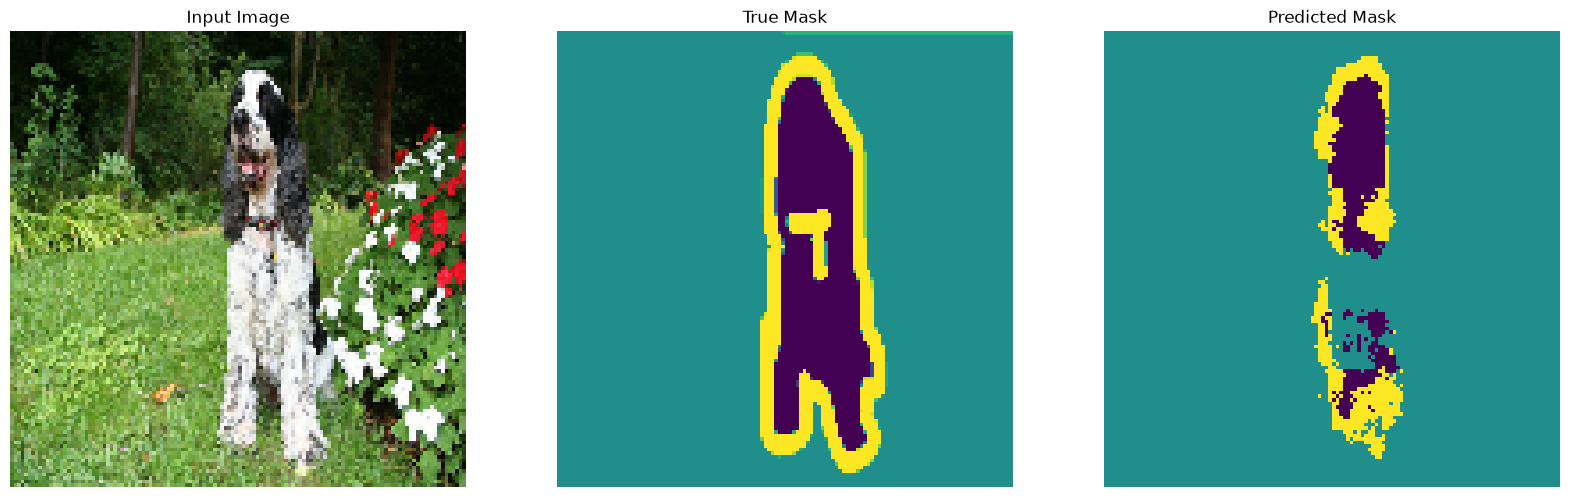


Sample Prediction after epoch10

57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 398ms/step - accuracy: 0.8615 - loss: 0.3225 - val_accuracy: 0.8674 - val_loss: 0.3124


In [ ]:

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
history = model.fit(
    train_dataset, 
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=test_dataset,
    callbacks=[DisplayCallback()],
)
models[model_name] = model
histories[model_name] = history

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


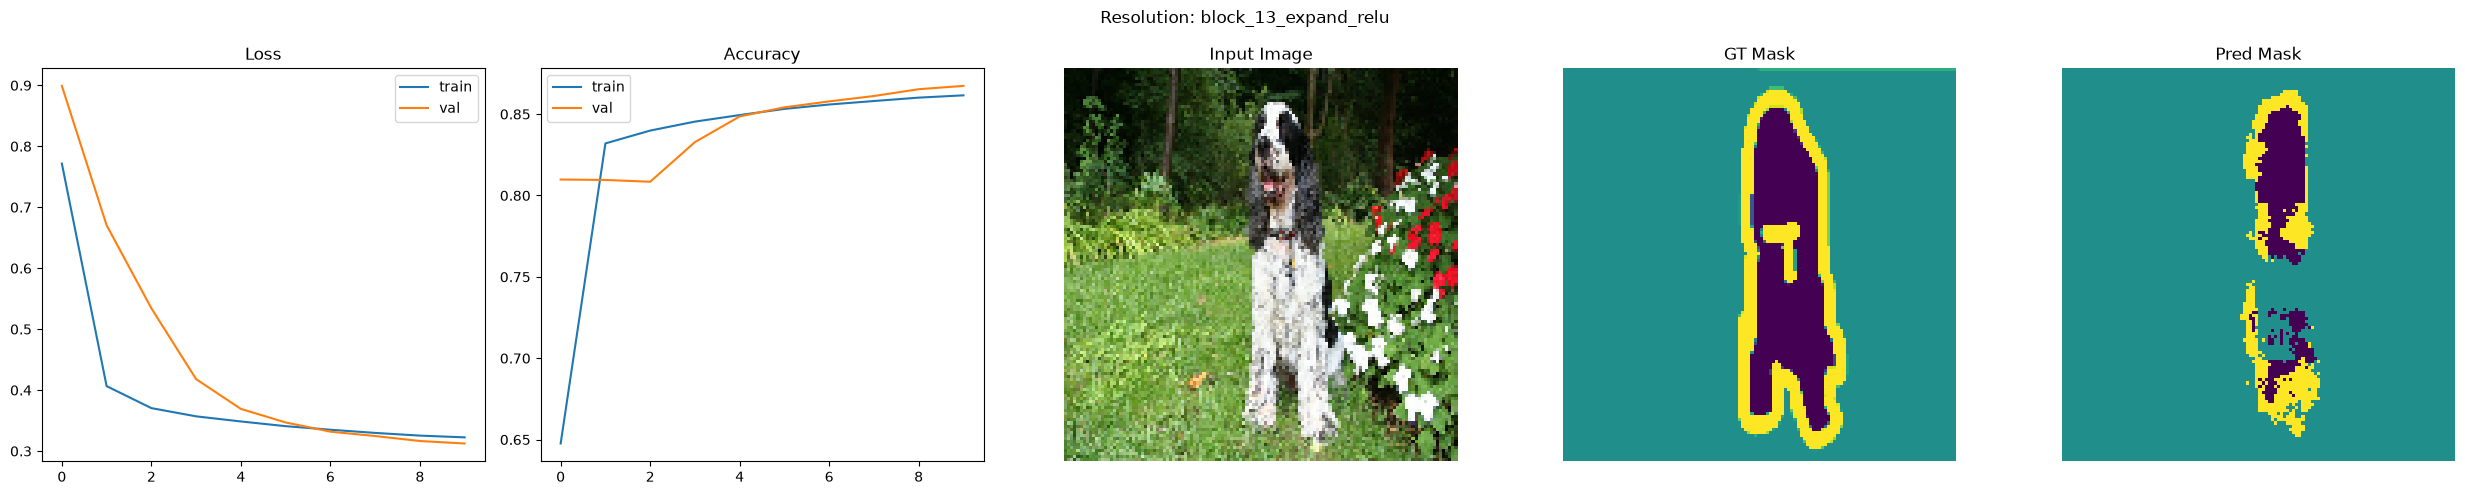

In [ ]:
name = 'block_13_expand_relu' 

# 정성평가
model = models[name]
history = histories[name]
pred_mask = create_mask(model.predict(sample_image[tf.newaxis, ...]))

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle(f"Resolution: {name}")
axes[0].plot(history.history['loss'], label='train'); axes[0].plot(history.history['val_loss'], label='val'); axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train'); axes[1].plot(history.history['val_accuracy'], label='val'); axes[1].set_title('Accuracy'); axes[1].legend()
axes[2].imshow(tf.keras.preprocessing.image.array_to_img(sample_image)); axes[2].set_title('Input Image'); axes[2].axis('off')
axes[3].imshow(tf.keras.preprocessing.image.array_to_img(sample_mask)); axes[3].set_title('GT Mask'); axes[3].axis('off')
axes[4].imshow(tf.keras.preprocessing.image.array_to_img(pred_mask)); axes[4].set_title('Pred Mask'); axes[4].axis('off')
plt.tight_layout()
plt.show()

In [140]:
# 정량평가
pixel_acc, dice_scores, iou_scores = compute_segmentation_metrics(models[name], test_dataset)
print(f"{name:<25} pixel_acc: {pixel_acc:.4f} dice: {dice_scores.mean():.4f} iou: {iou_scores.mean():.4f}")

block_13_expand_relu      pixel_acc: 0.8672 dice: 0.7329 iou: 0.6281


#### task5. U-Net Implementation

* convolution transpose + concatenation 적절하게 활용
* Conv2DTranspose channel 수는 6으로 고정
* 4x4를 Conv2D Transpose 를 이용해서 8x8로 만들고, 기존의 backbone_featrues의 8x8과 concatenation
* 반복해서 128x128 까지

In [160]:
def build_unet():
    def deconvs(filters, size):
        return tf.keras.Sequential([
            tf.keras.layers.Conv2DTranspose(filters, size, strides=2, padding='same'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
        ])
    
    up_stack = [
        deconvs(16, 3),  # 4*4 -> 8*8
        deconvs(16, 3),  # 8*8 -> 16*16
        deconvs(16, 3),  # 16*16 -> 32*32
        deconvs(16, 3),  # 32*32 -> 64*64
    ]
    
    # input shape
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])
    x = inputs

    # feature
    features = backbone_features(x)
    x = features[-1]
    skips = reversed(features[:-1])
    
    # upsampling + concatenation
    for up, skip in zip(up_stack, skips):
        x = up(x)
        concat = tf.keras.layers.Concatenate()
        x = concat([x, skip])

    last = tf.keras.layers.Conv2DTranspose(OUTPUT_CHANNELS, 3, strides=2, padding='same')
    x= last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

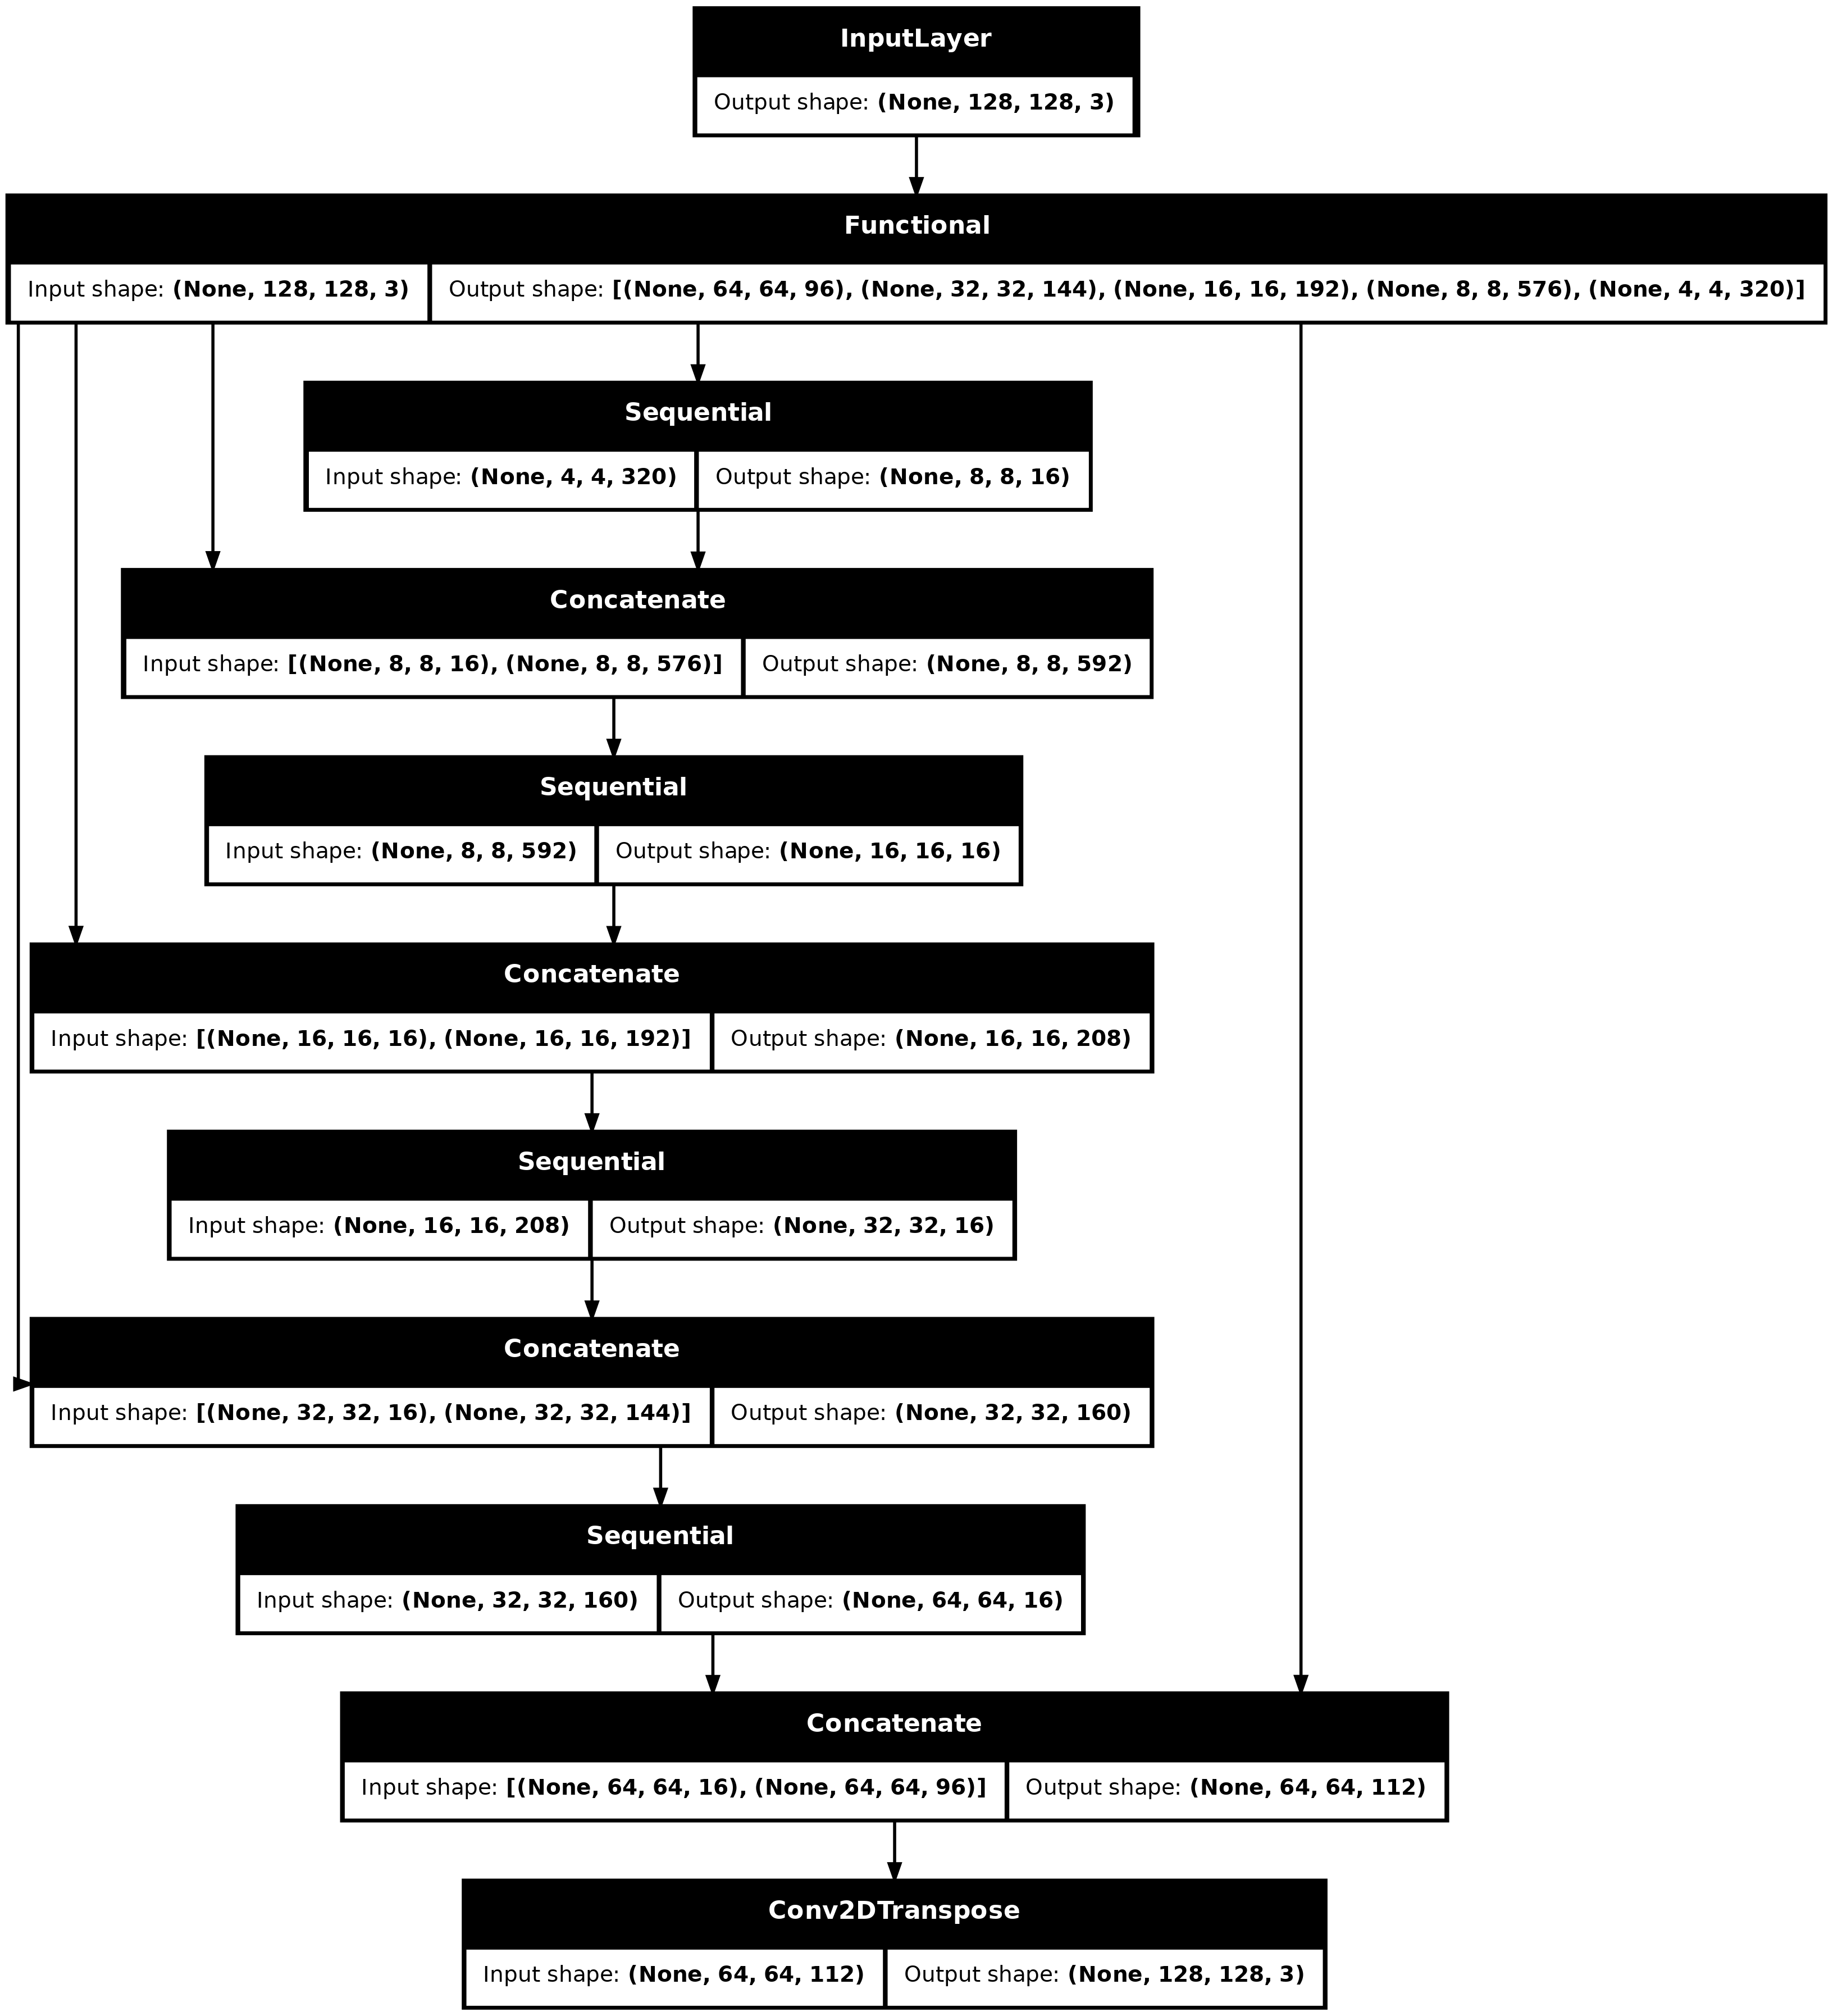

In [164]:
tf.keras.utils.plot_model(model, show_shapes=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


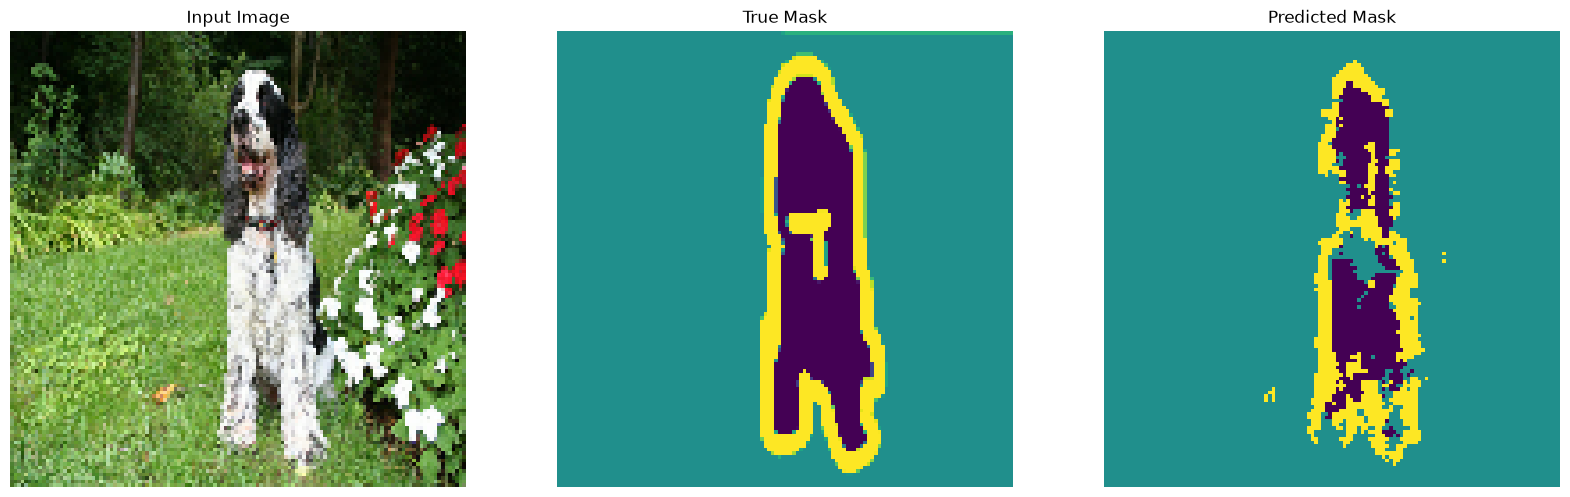


Sample Prediction after epoch10

57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 421ms/step - accuracy: 0.8906 - loss: 0.2629 - val_accuracy: 0.8941 - val_loss: 0.2597


In [161]:
model_name = 'block' 
model = build_unet()
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
history = model.fit(
    train_dataset, 
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    validation_data=test_dataset,
    callbacks=[DisplayCallback()],
)
models[model_name] = model
histories[model_name] = history

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


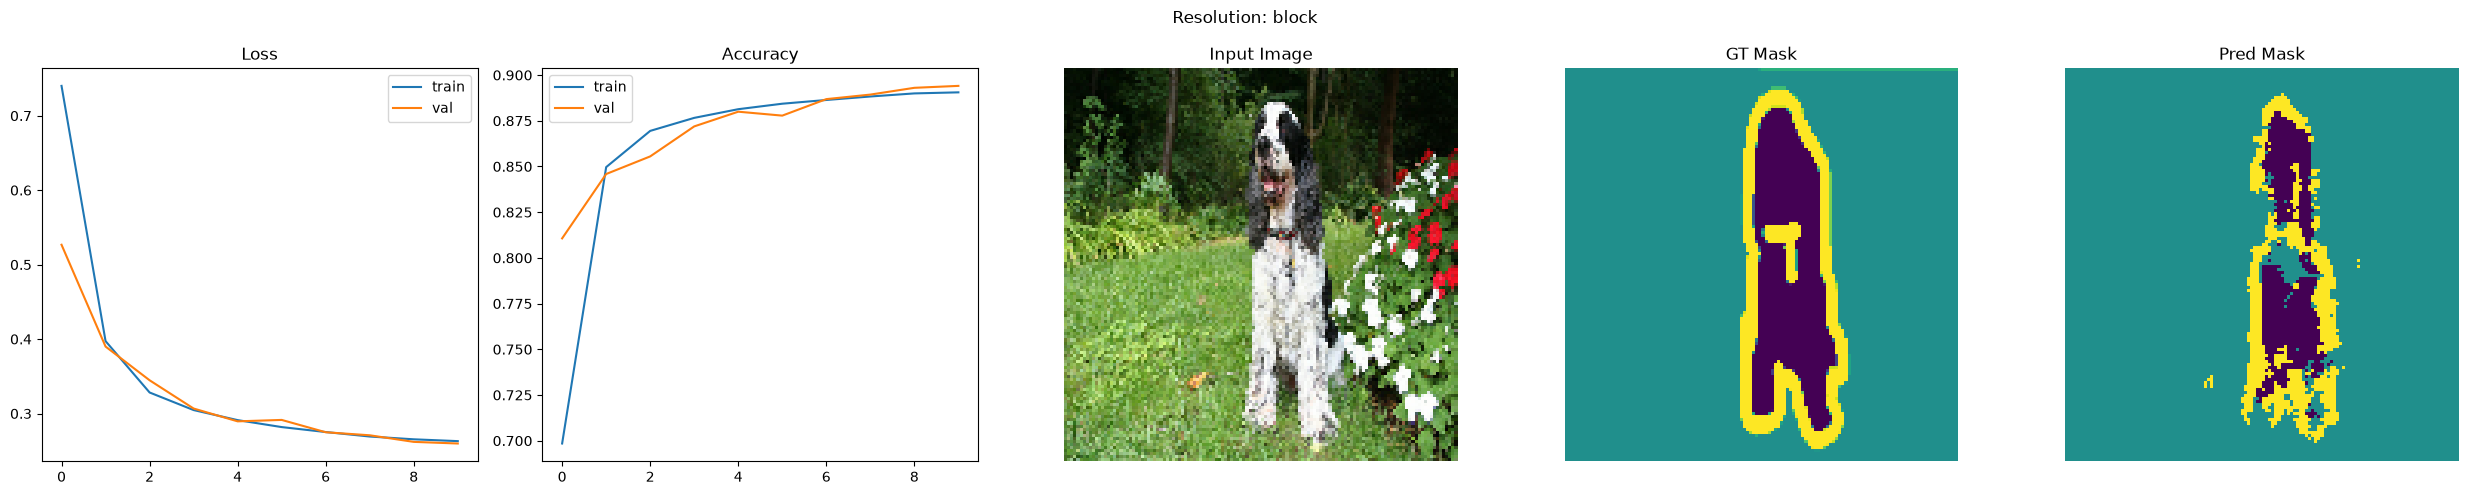

In [162]:
name = 'block'

# 정성평가
model = models[name]
history = histories[name]
pred_mask = create_mask(model.predict(sample_image[tf.newaxis, ...]))

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle(f"Resolution: {name}")
axes[0].plot(history.history['loss'], label='train'); axes[0].plot(history.history['val_loss'], label='val'); axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train'); axes[1].plot(history.history['val_accuracy'], label='val'); axes[1].set_title('Accuracy'); axes[1].legend()
axes[2].imshow(tf.keras.preprocessing.image.array_to_img(sample_image)); axes[2].set_title('Input Image'); axes[2].axis('off')
axes[3].imshow(tf.keras.preprocessing.image.array_to_img(sample_mask)); axes[3].set_title('GT Mask'); axes[3].axis('off')
axes[4].imshow(tf.keras.preprocessing.image.array_to_img(pred_mask)); axes[4].set_title('Pred Mask'); axes[4].axis('off')
plt.tight_layout()
plt.show()

In [163]:
# 정량평가
pixel_acc, dice_scores, iou_scores = compute_segmentation_metrics(models[name], test_dataset)
print(f"{name:<25} pixel_acc: {pixel_acc:.4f} dice: {dice_scores.mean():.4f} iou: {iou_scores.mean():.4f}")

block                     pixel_acc: 0.8957 dice: 0.8041 iou: 0.7040
